# Best runs & ranking — ΔSnow vs. HS2SWE vs. Mag25 obs

Loads the station × season metrics and daily timeseries produced by
`run_all_stations_seasons_metrics.R` (this directory).

**Notebook structure**

1. **Setup** — paths, thresholds, data loading
2. **Ranking table** — all station × season runs, best to worst
   (SWE and HNW combined: mean of the RMSE ranks of both variables, per model)
3. **Elevation-band statistics** — mean metrics per elevation band and model
4. **Plot helper** — single station × season figure (SWE panel + metrics table),
   restricted to the core snow season (1 Oct – 31 May)
5. **Single-station season figures** — render & save chosen runs
6. **Station map** — pooled per-station metrics on a Swiss map, stations labelled

Runs with too few observations are excluded from ranking/best-run selection
(`MIN_N_SWE`, `MIN_N_HNW` below) — with e.g. 2 snow-course days an R² of 1.00
is meaningless.

In [74]:
from pathlib import Path

# Project root - located through the .projectroot marker file, so this
# notebook runs from any checkout location.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / ".projectroot").exists())

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

HERE = ROOT / "single_station_season_comparison"
sys.path.insert(0, str(HERE.parent))
from plot_style import apply_style, C, FIG

apply_style()

METRICS_CSV    = HERE / "metrics_all_stations_seasons.csv"
TIMESERIES_CSV = HERE / "timeseries_all_stations_seasons.csv"

# Minimum paired obs for a run to enter ranking / best-run selection
MIN_N_SWE = 5
MIN_N_HNW = 50

MODEL_LABEL = {
    "dSnow_default":  "\u0394Snow default",
    "dSnow_best_new": "\u0394Snow best_new",
    "HS2SWE":         "HS2SWE",
}

met = pd.read_csv(METRICS_CSV)
ts  = pd.read_csv(TIMESERIES_CSV, parse_dates=["date"])
print(f"metrics:    {met.shape[0]} rows  ({met.station.nunique()} stations, "
      f"{met.season.nunique()} seasons, {met.model.nunique()} models)")
print(f"timeseries: {ts.shape[0]} rows")
met.head(3)

metrics:    720 rows  (40 stations, 6 seasons, 3 models)
timeseries: 87640 rows


,station,season,model,swe_rmse,swe_rel_bias,swe_r2,swe_n,hnw_rmse,hnw_rel_bias,hnw_r2,hnw_n
0,Adelboden,2016_2017,dSnow_default,7.789303,3.145951,0.663448,4,1.406820,-17.297055,0.888552,152
1,Adelboden,2016_2017,dSnow_best_new,8.537649,10.567966,0.857389,4,1.598894,3.943771,0.889204,152
2,Adelboden,2016_2017,HS2SWE,7.973213,2.923725,0.701359,4,1.937755,14.423908,0.886541,152


## Ranking — best to worst, SWE and HNW combined

Per model, every valid station × season run is ranked by `swe_rmse` and by
`hnw_rmse` (ascending); the **combined score is the mean of the two ranks**.
Rank 1 = best.

In [75]:
valid = met[(met.swe_n >= MIN_N_SWE) & (met.hnw_n >= MIN_N_HNW)].copy()
print(f"{len(valid)} of {len(met)} runs pass the n-thresholds "
      f"(swe_n >= {MIN_N_SWE}, hnw_n >= {MIN_N_HNW})\n")

def add_ranks(g):
    g = g.copy()
    g["rank_swe"] = g.swe_rmse.rank()
    g["rank_hnw"] = g.hnw_rmse.rank()
    g["score"]    = (g.rank_swe + g.rank_hnw) / 2
    g["rank"]     = g.score.rank(method="first").astype(int)
    return g.sort_values("rank")

ranking = pd.concat(
    [add_ranks(g) for _, g in valid.groupby("model")], ignore_index=True
)

cols = ["rank", "station", "season", "swe_rmse", "swe_rel_bias", "swe_r2", "swe_n",
        "hnw_rmse", "hnw_rel_bias", "hnw_r2", "hnw_n", "score"]

for model in ["dSnow_default", "dSnow_best_new", "HS2SWE"]:
    tbl = ranking[ranking.model == model][cols].round(2)
    print(f"── {MODEL_LABEL[model]} — ranking best → worst "
          f"({len(tbl)} runs) " + "─" * 30)
    with pd.option_context("display.max_rows", None, "display.width", 160):
        print(tbl.to_string(index=False))
    print()

357 of 720 runs pass the n-thresholds (swe_n >= 5, hnw_n >= 50)

── ΔSnow default — ranking best → worst (119 runs) ──────────────────────────────
 rank          station    season  swe_rmse  swe_rel_bias  swe_r2  swe_n  hnw_rmse  hnw_rel_bias  hnw_r2  hnw_n  score
    1        Adelboden 2020_2021      7.21         -0.93    0.95      7      0.95          6.30    0.94    152    2.5
    2             Zuoz 2021_2022      9.49         -4.01    0.92      5      0.77         -8.36    0.96    148    3.0
    3          Samnaun 2021_2022     13.41         -0.70    0.94      6      1.01         -4.59    0.95    149    9.0
    4        Adelboden 2021_2022     14.32          1.32    0.83      8      0.82          0.31    0.98    153   10.0
    5             Zuoz 2019_2020     14.59         10.63    0.95      9      1.00        -19.28    0.98    150   12.5
    6         Saas_Fee 2021_2022     17.92        -11.60    0.82      7      0.77        -11.88    0.98    159   15.0
    7            Bivio 2016

## Elevation-band statistics — mean metrics per band and model

Station altitudes come from `Mag25_all.nc`; coordinates are converted
LV03 → WGS84 with the swisstopo approximation formulas (also reused by the
station map below). Bands: **< 1500 m**, **1500–2000 m**, **> 2000 m**.

Mean of the per-run (station × season) metrics over all **valid** runs
(`swe_n >= MIN_N_SWE`, `hnw_n >= MIN_N_HNW`) in each band, per model.

In [76]:
import xarray as xr

# ── Station coordinates & altitude (Mag25_all.nc, LV03 → WGS84) ──────────────
MAG25_NC = ROOT / "calibration/calibration_data/raw_data/mag25/slf_dataset/Mag25_all.nc"

ds_mag = xr.open_dataset(MAG25_NC)
coords = ds_mag[["easting", "northing", "altitude"]].to_dataframe()
yy = (coords.easting  - 600_000) / 1e6
xx = (coords.northing - 200_000) / 1e6
coords["lon"] = (2.6779094 + 4.728982 * yy + 0.791484 * yy * xx
                 + 0.1306 * yy * xx**2 - 0.0436 * yy**3) * 100 / 36
coords["lat"] = (16.9023892 + 3.238272 * xx - 0.270978 * yy**2
                 - 0.002528 * xx**2 - 0.0447 * yy**2 * xx
                 - 0.0140 * xx**3) * 100 / 36

# ── Elevation bands (label, lo, hi, map marker) ───────────────────────────────
ELEV_BANDS = [
    ("< 1500 m",    -np.inf, 1500,   "o"),
    ("1500–2000 m",    1500, 2000,   "^"),
    ("> 2000 m",       2000, np.inf, "s"),
]
BAND_LABELS = [b[0] for b in ELEV_BANDS]
coords["band"] = pd.cut(coords.altitude, bins=[-np.inf, 1500, 2000, np.inf],
                        labels=BAND_LABELS)

# ── Mean metrics per band × model (valid runs only) ──────────────────────────
met_b = valid.merge(coords[["altitude", "band"]],
                    left_on="station", right_index=True, how="left")
missing = met_b[met_b.band.isna()].station.unique().tolist()
if missing:
    print(f"no altitude for: {', '.join(missing)} — excluded from band stats")

metric_cols = ["swe_rmse", "swe_rel_bias", "swe_r2",
               "hnw_rmse", "hnw_rel_bias", "hnw_r2"]
band_stats = (
    met_b.dropna(subset=["band"])
    .groupby(["band", "model"], observed=True)
    .agg(n_stations=("station", "nunique"), n_runs=("station", "size"),
         **{c: (c, "mean") for c in metric_cols})
    .reindex(pd.MultiIndex.from_product([BAND_LABELS, list(MODEL_LABEL)],
                                        names=["band", "model"]))
    .rename(index=MODEL_LABEL, level="model")
)
band_stats.columns = pd.MultiIndex.from_tuples([
    ("runs",  "stations"), ("runs",  "n"),
    ("SWE",   "RMSE [mm]"), ("SWE",  "rel. bias [%]"), ("SWE", "R²"),
    ("HNW",   "RMSE [mm]"), ("HNW",  "rel. bias [%]"), ("HNW", "R²"),
])
band_stats.round(2)

runs           SWE                      \
                           stations   n RMSE [mm] rel. bias [%]    R²   
band        model                                                       
< 1500 m    ΔSnow default        10  55     27.64         -3.99  0.92   
            ΔSnow best_new       10  55     30.56          5.85  0.90   
            HS2SWE               10  55     24.67          1.07  0.93   
1500–2000 m ΔSnow default        11  58     31.60         -0.76  0.89   
            ΔSnow best_new       11  58     35.21          8.34  0.87   
            HS2SWE               11  58     29.89          4.52  0.90   
> 2000 m    ΔSnow default         1   6     26.65         -6.37  0.93   
            ΔSnow best_new        1   6     28.15          4.52  0.95   
            HS2SWE                1   6     25.03          2.67  0.95   

                                 HNW                      
                           RMSE [mm] rel. bias [%]    R²  
band        model                                         
< 1500 m    ΔSnow default       3.16        -20.16  0.88  
            ΔSnow best_new      3.01         -2.85  0.88  
            HS2SWE              2.96          0.46  0.88  
1500–2000 m ΔSnow default       2.71        -12.25  0.89  
            ΔSnow best_new      2.75          6.80  0.89  
            HS2SWE              2.62         10.09  0.90  
> 2000 m    ΔSnow default       2.19          0.63  0.90  
            ΔSnow best_new      2.64         20.11  0.91  
            HS2SWE              2.50         22.72  0.93

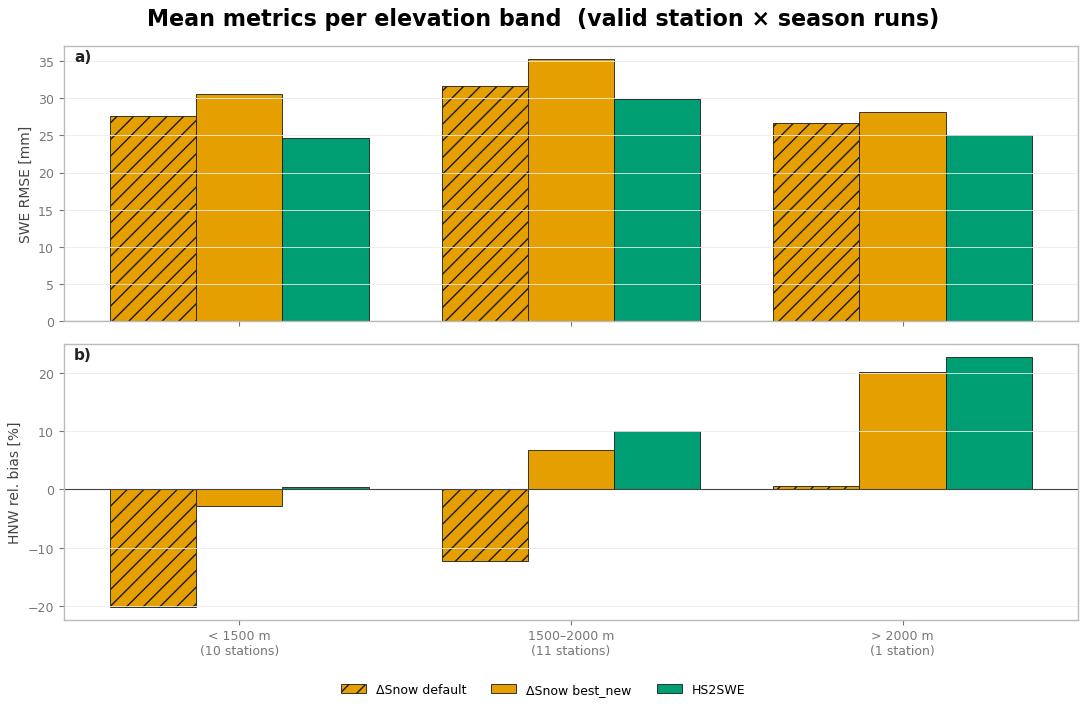

In [83]:
# ── Barplot: mean metrics per elevation band and model ───────────────────────
from plot_style import add_subplot_labels

PANELS = [
    (("SWE", "RMSE [mm]"),     "SWE RMSE [mm]"),
    #(("SWE", "rel. bias [%]"), "SWE rel. bias [%]"),
    #(("HNW", "RMSE [mm]"),     "HNW RMSE [mm]"),
    (("HNW", "rel. bias [%]"), "HNW rel. bias [%]"),
]
BAR_STYLE = {  # model → (colour, hatch): ΔSnow variants share the hue, default hatched
    "\u0394Snow default":  (C.DSNOW,  "//"),
    "\u0394Snow best_new": (C.DSNOW,  ""),
    "HS2SWE":               (C.HS2SWE, ""),
}
models = list(BAR_STYLE)

n_stn  = band_stats[("runs", "stations")].groupby(level="band", observed=True) \
                                          .first().reindex(BAND_LABELS)
xticks = [f"{b}\n({int(n)} station{'s' if n > 1 else ''})" for b, n in n_stn.items()]

x = np.arange(len(BAND_LABELS))
w = 0.26

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
for ax, (col, ylabel) in zip(axes.ravel(), PANELS):
    for i, m in enumerate(models):
        vals = [band_stats.loc[(b, m), col] for b in BAND_LABELS]
        colr, hatch = BAR_STYLE[m]
        ax.bar(x + (i - 1) * w, vals, width=w, color=colr, hatch=hatch,
               edgecolor="#1A1A1A", linewidth=0.6, label=m)
    ax.axhline(0, color="#444444", lw=0.8)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(xticks)

add_subplot_labels(axes)

#handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Mean metrics per elevation band  (valid station \u00d7 season runs)")
fig.tight_layout(rect=(0, 0.03, 1, 1))
fig.savefig(HERE / "band_stats_barplot.png", **FIG.SAVE)
plt.show()

## Plot helper — replica of the `single_station_season_comparison.R` figure

Single SWE panel: ΔSnow default (dashed, `C.DSNOW`), ΔSnow best_new (solid,
`C.DSNOW`), HS2SWE (solid, `C.HS2SWE`), Mag25 SWE obs as black points, observed
HS as thin grey dashed line in the background on a secondary y-axis.

Only the core snow season **1 Oct – 31 May** is plotted; the x-axis is framed
to that window for every station/season so figures are comparable.

Below the panel the metrics are rendered as a proper table (horizontal rules
per row, vertical rule separating the SWE and HNW column groups).

In [78]:
# ── Plot helper: one station × season, SWE panel + metrics table ─────────────
C_HS = C.HS  # mid-grey, auxiliary snow height

SNOW_MONTHS = [10, 11, 12, 1, 2, 3, 4, 5]   # plotted window: 1 Oct – 31 May


def draw_metric_table(ax_tbl, station, season):
    """Metrics table with row rules and a SWE | HNW group separator."""
    rows = met[(met.station == station) & (met.season == season)]

    headers = ["Model", "RMSE [mm]", "rel. bias [%]", "R²", "n",
               "RMSE [mm]", "rel. bias [%]", "R²", "n"]
    body = []
    for model in ["dSnow_default", "dSnow_best_new", "HS2SWE"]:
        r = rows[rows.model == model].iloc[0]
        body.append([
            MODEL_LABEL[model],
            f"{r.swe_rmse:.1f}", f"{r.swe_rel_bias:.1f}", f"{r.swe_r2:.2f}", f"{r.swe_n:.0f}",
            f"{r.hnw_rmse:.2f}", f"{r.hnw_rel_bias:.1f}", f"{r.hnw_r2:.2f}", f"{r.hnw_n:.0f}",
        ])

    ax_tbl.axis("off")

    # Model column wide, then 4 SWE + 4 HNW columns (sums to 1.0)
    col_w = [0.26] + [0.11, 0.12, 0.08, 0.06] * 2
    tbl = ax_tbl.table(cellText=body, colLabels=headers, colWidths=col_w,
                       cellLoc="center", bbox=[0.0, 0.0, 1.0, 0.74])
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_facecolor("none")
        cell.set_edgecolor("#AAAAAA")
        cell.set_linewidth(0.8)
        edges = "BT" if row == 0 else "B"   # rule above/below header, below each row
        if col == 5:
            edges += "L"                    # vertical SWE | HNW separator
        cell.visible_edges = edges
        txt = cell.get_text()
        txt.set_color("#333333")
        if row == 0:
            txt.set_fontweight("bold")
        if col == 0:
            cell._loc = "left"              # left-align model names
            cell.PAD = 0.03

    # Column-group titles with cmidrule-style underlines
    ax_tbl.text(0.445, 0.88, "SWE (vs. biweekly obs)", transform=ax_tbl.transAxes,
                ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#333333")
    ax_tbl.text(0.815, 0.88, "HNW (vs. daily obs)", transform=ax_tbl.transAxes,
                ha="center", va="bottom", fontsize=8.5, fontweight="bold", color="#333333")
    for x0, x1 in [(0.27, 0.62), (0.64, 0.99)]:
        ax_tbl.plot([x0, x1], [0.86, 0.86], transform=ax_tbl.transAxes,
                    color="#AAAAAA", lw=0.8, clip_on=False)


def plot_station_season(station, season):
    """SWE panel (1 Oct – 31 May) with HS in the background + metrics table."""
    d = ts[(ts.station == station) & (ts.season == season)].sort_values("date")
    if d.empty:
        raise ValueError(f"no timeseries for {station} {season}")

    # Core snow season only — also cuts the drawn lines, not just the view
    d = d[d.date.dt.month.isin(SNOW_MONTHS)]
    if d.empty:
        raise ValueError(f"no Oct–May data for {station} {season}")

    fig, (ax, ax_tbl) = plt.subplots(
        2, 1, figsize=(FIG.SINGLE[0], 6.6),
        gridspec_kw={"height_ratios": [4.8, 1.8], "hspace": 0.25},
    )

    # Snow height in the background on a secondary y-axis
    ax_hs = ax.twinx()
    ax_hs.plot(d.date, d.hs_obs_m, color=C_HS, ls="--", lw=1.1, zorder=1)
    ax_hs.set_ylabel("HS [m]")
    ax_hs.set_ylim(bottom=0, top = ( d.swe_obs_mm.max() * 1.3 )/ 100)
    ax_hs.grid(False)

    # Model lines
    ax.plot(d.date, d.swe_dsnow_default,  color=C.DSNOW,  ls="--", zorder=3)
    ax.plot(d.date, d.swe_dsnow_best_new, color=C.DSNOW,  ls="-",  zorder=3)
    ax.plot(d.date, d.swe_hs2swe,         color=C.HS2SWE, ls="-",  zorder=3)

    # Mag25 SWE obs: black points only (biweekly snow-course days)
    ok = d.swe_obs_mm.notna()
    ax.plot(d.date[ok], d.swe_obs_mm[ok], "o", color=C.OBS, ms=4, zorder=4)

    ax.set_ylabel("SWE [mm]")
    ax.set_ylim(bottom=0, top=d.swe_obs_mm.max() * 1.2)
    ax.set_zorder(ax_hs.get_zorder() + 1)   # SWE axis above the HS line
    ax.patch.set_visible(False)
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # Frame the axis to the full Oct–May window (season = "YYYY_YYYY")
    start_year = int(season.split("_")[0])
    ax.set_xlim(pd.Timestamp(start_year, 10, 1),
                pd.Timestamp(start_year + 1, 5, 31))

    title = (f"{station.replace('_', ' ')} \u2014 season {season.replace('_', '/')}: "
             f"\u0394Snow vs. HS2SWE vs. Mag25 obs")
    ax.set_title(title)

    handles = [
        plt.Line2D([], [], color=C.OBS, marker="o", ls="", ms=4,
                   label="Mag25 SWE obs"),
        plt.Line2D([], [], color=C.DSNOW, ls="--", label="\u0394Snow default"),
        plt.Line2D([], [], color=C.DSNOW, ls="-",  label="\u0394Snow best_new"),
        plt.Line2D([], [], color=C.HS2SWE, ls="-", label="HS2SWE"),
        plt.Line2D([], [], color=C_HS, ls="--", lw=1.1,
                   label="HS obs (right axis)"),
    ]
    ax.legend(handles=handles, loc="upper left")

    # Metrics table below the panel
    draw_metric_table(ax_tbl, station, season)

    plt.show()
    return fig

## Single-station season figures

Render and save the figure for a chosen station × season.

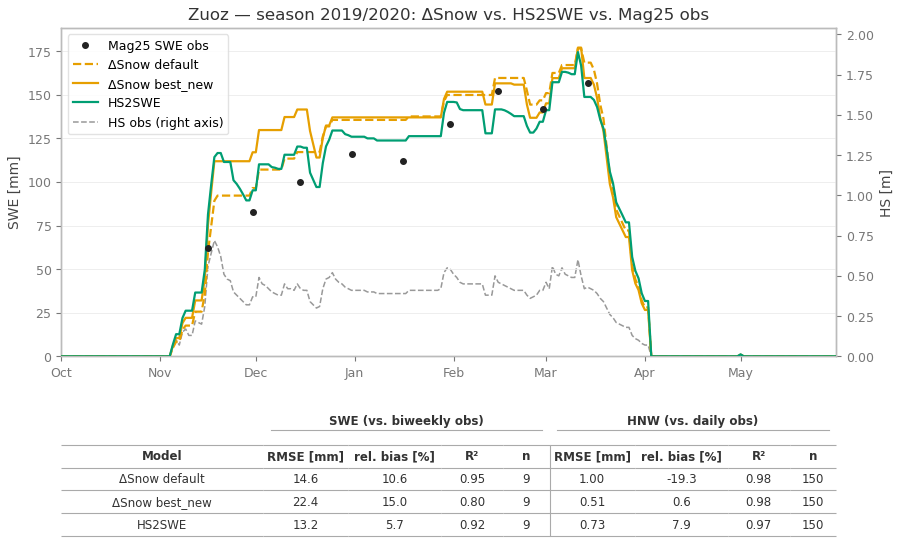

In [84]:
STATION, SEASON = "Zuoz", "2019_2020"

fig = plot_station_season(STATION, SEASON)
fig.savefig(HERE / f"station_{STATION}_{SEASON}.png", **FIG.SAVE)

## Station map — SWE RMSE (marker size), |HNW rel. bias| (colour), elevation band (marker shape)

Base map reused from `supp/data_char_climate/Map/overview.ipynb`. Per station,
metrics are **pooled across all seasons** for `MAP_MODEL` (paired days of all
6 seasons combined):

- **marker size** ∝ SWE RMSE [mm]
- **colour** = |HNW rel. bias| [%], sequential Reds (darker = larger bias magnitude)
- **marker shape** = elevation band: ● < 1500 m, ▲ 1500–2000 m, ■ > 2000 m
- every station is labelled by name

Station coordinates come from `Mag25_all.nc` (easting/northing, Swiss LV03),
converted to WGS84 with the official swisstopo approximation formulas
(`stations_merged.csv` only carries SLF codes, not the Mag25 station names).

In [80]:
MAP_MODEL = "dSnow_best_new"          # "dSnow_default" | "dSnow_best_new" | "HS2SWE"
SWE_COL   = {"dSnow_default":  "swe_dsnow_default",
             "dSnow_best_new": "swe_dsnow_best_new",
             "HS2SWE":         "swe_hs2swe"}[MAP_MODEL]

# ── Pooled per-station metrics (all seasons combined) ────────────────────────
t = ts.sort_values(["station", "season", "date"]).copy()
# HNW within each station × season (no diff across season boundaries), melt → 0
t["hnw_mod"] = t.groupby(["station", "season"])[SWE_COL].diff().clip(lower=0)

def pooled_metrics(g):
    swe_ok = g.swe_obs_mm.notna() & g[SWE_COL].notna()
    hnw_ok = g.hnw_obs_mm.notna() & g.hnw_mod.notna()
    return pd.Series({
        "swe_rmse":     np.sqrt(((g[SWE_COL] - g.swe_obs_mm)[swe_ok] ** 2).mean()),
        "hnw_rel_bias": 100 * (g.hnw_mod - g.hnw_obs_mm)[hnw_ok].sum()
                            / g.hnw_obs_mm[hnw_ok].sum(),
        "swe_n":        swe_ok.sum(),
        "hnw_n":        hnw_ok.sum(),
    })

stn = pd.concat({s: pooled_metrics(g) for s, g in t.groupby("station")},
                axis=1).T.rename_axis("station")

# Coordinates, altitude and elevation band from the band-stats section
stn = stn.join(coords[["lon", "lat", "altitude", "band"]]).reset_index()

# Stations without a single SWE obs (or HNW obs) cannot be shown
dropped = stn[stn.swe_rmse.isna() | stn.hnw_rel_bias.isna()].station.tolist()
if dropped:
    print(f"dropped (no SWE/HNW obs in any season): {', '.join(dropped)}")
stn = stn[stn.swe_rmse.notna() & stn.hnw_rel_bias.notna()].copy()

print(f"{MAP_MODEL}: pooled metrics for {len(stn)} stations")
print(stn.band.value_counts().to_string())
stn.round(2).head()

dropped (no SWE/HNW obs in any season): Binn, Bosco_Gurin, Gadmen, Grimentz, Grindelwald_Bort, Lauchernalp, Leysin, Montana, Obersaxen, Pusserein, Saanenmoeser, Sankt_Moritz, Simplon_Dorf, Srenberg, St_Antoenien, St_Margrethenberg, Vals, Wengen
dSnow_best_new: pooled metrics for 22 stations
band
1500–2000 m    11
< 1500 m       10
> 2000 m        1


,station,swe_rmse,hnw_rel_bias,swe_n,hnw_n,lon,lat,altitude,band
0,Adelboden,14.98,18.52,32.0,906.0,7.57,46.50,1350,< 1500 m
2,Bivio,29.78,-10.89,58.0,817.0,9.65,46.47,1770,1500–2000 m
4,Bourg_St_Pierre,16.06,3.87,31.0,851.0,7.21,45.95,1670,1500–2000 m
5,Braunwald,45.81,-4.71,52.0,912.0,8.99,46.94,1310,< 1500 m
6,Davos_Flueelastr,52.71,17.47,51.0,811.0,9.85,46.81,1560,1500–2000 m


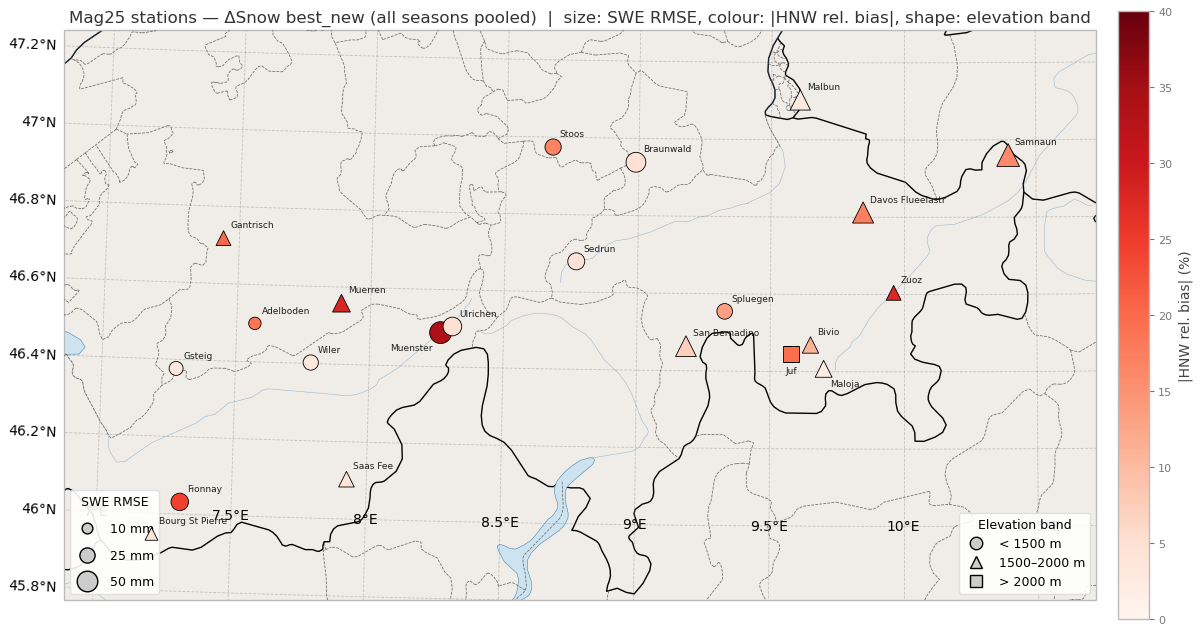

In [81]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ── Colour: HNW rel. bias, diverging, centred at 0 ───────────────────────────
bias_max = np.ceil(stn.hnw_rel_bias.abs().max() / 10) * 10
cmap = plt.get_cmap("Reds")
norm = mcolors.Normalize(vmin=0, vmax=bias_max)

# ── Size: SWE RMSE [mm] ──────────────────────────────────────────────────────
def rmse_size(rmse):
    return 20 + 4.0 * np.asarray(rmse, dtype=float)

SIZE_REF = [10, 25, 50]   # mm, legend reference

# ── Map extent ────────────────────────────────────────────────────────────────
lon_min, lon_max = stn.lon.min(), stn.lon.max()
lat_min, lat_max = stn.lat.min(), stn.lat.max()
lon_pad = (lon_max - lon_min) * 0.10
lat_pad = (lat_max - lat_min) * 0.12

proj = ccrs.LambertConformal(central_longitude=10.0, central_latitude=46.5,
                             standard_parallels=(44, 49))

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8), subplot_kw={"projection": proj})
ax.set_extent(
    [lon_min - lon_pad, lon_max + lon_pad,
     lat_min - lat_pad, lat_max + lat_pad],
    crs=ccrs.PlateCarree()
)

# ── Base map features (as in supp/data_char_climate/Map/overview.ipynb) ──────
ax.add_feature(cfeature.LAND,      facecolor="#f0ede8")
ax.add_feature(cfeature.OCEAN,     facecolor="#cde4f0")
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=1.0, edgecolor="black")
ax.add_feature(cfeature.RIVERS,    linewidth=0.4, edgecolor="steelblue", alpha=0.5)
ax.add_feature(cfeature.LAKES,     facecolor="#cde4f0", edgecolor="steelblue", linewidth=0.4)

provinces = cfeature.NaturalEarthFeature(
    category="cultural", name="admin_1_states_provinces_lines",
    scale="10m", facecolor="none"
)
ax.add_feature(provinces, edgecolor="dimgrey", linewidth=0.55, linestyle="--", zorder=3)

gl = ax.gridlines(draw_labels=True, linestyle="--", alpha=0.4, color="grey")
gl.top_labels   = False
gl.right_labels = False

# ── Scatter: one call per elevation band (marker shape) ──────────────────────
for label, lo, hi, marker in ELEV_BANDS:
    sub = stn[stn.band == label]
    if sub.empty:
        continue
    ax.scatter(
        sub.lon, sub.lat,
        s=rmse_size(sub.swe_rmse), marker=marker,
        c=sub.hnw_rel_bias.abs(), cmap=cmap, norm=norm,
        edgecolor="black", linewidth=0.6,
        transform=ccrs.PlateCarree(), zorder=6,
    )

# ── Station name labels (manual offsets where labels would collide) ──────────
LABEL_OFFSET = {                      # (dx, dy, ha, va)
    "Muenster": (-0.030, -0.028, "right", "top"),
    "Juf":      ( 0.000, -0.032, "center", "top"),
    "Maloja":   ( 0.025, -0.028, "left",  "top"),
}
for _, row in stn.iterrows():
    dx, dy, ha, va = LABEL_OFFSET.get(row.station, (0.025, 0.022, "left", "bottom"))
    ax.text(row.lon + dx, row.lat + dy, row.station.replace("_", " "),
            transform=ccrs.PlateCarree(), fontsize=6.5, color="#1f1f1f",
            ha=ha, va=va, zorder=7)

# ── Colorbar: HNW rel. bias ──────────────────────────────────────────────────
sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="vertical", fraction=0.028, pad=0.02)
cbar.set_label("|HNW rel. bias| (%)", fontsize=10)
cbar.ax.tick_params(labelsize=8)

# ── Legends: elevation-band shapes + SWE-RMSE sizes ──────────────────────────
shape_handles = [
    Line2D([], [], ls="", marker=m, markerfacecolor="#CCCCCC",
           markeredgecolor="black", markersize=9, label=lbl)
    for lbl, lo, hi, m in ELEV_BANDS
]
leg1 = ax.legend(handles=shape_handles, title="Elevation band",
                 loc="lower right", fontsize=9, title_fontsize=9, framealpha=0.9)
ax.add_artist(leg1)

size_handles = [
    Line2D([], [], ls="", marker="o", markerfacecolor="#CCCCCC",
           markeredgecolor="black",
           markersize=np.sqrt(rmse_size(v)), label=f"{v} mm")
    for v in SIZE_REF
]
ax.legend(handles=size_handles, title="SWE RMSE",
          loc="lower left", fontsize=9, title_fontsize=9,
          framealpha=0.9, labelspacing=1.1)

ax.set_title(f"Mag25 stations — {MODEL_LABEL[MAP_MODEL]} (all seasons pooled)  |  "
             f"size: SWE RMSE, colour: |HNW rel. bias|, shape: elevation band",
             fontsize=12)
plt.savefig(HERE / f"stations_map_metrics_{MAP_MODEL}.png",
            dpi=180, bbox_inches="tight")
plt.show()